# Synthetic Ramesside Star Clocks

In [1]:
# set up paths to local module
import sys 
from pathlib import Path
PROJECT_ROOT = Path().resolve().parents[0]
sys.path.append(str(PROJECT_ROOT))

import decanopy


### Import Sky & Initialize 

In [2]:
from decanopy.skyproc.sky_processing import initialize_sky

### Choose sky data for synRSC calculations
# -----------------------------------------------------------------------------
# Two current options are listed below; 
# the "hippdata1300BC.txt" and "mockdata_518_1300BC-Mar-18-2024_1059.txt" don't ship with GitHub,
# so they have to be manually added to the correct folders! 
# Will also need star_data_Mar-18-2024_1059.csv for OPTION 2. It must exist in /data/input/skyflow/rand_sky/.

# For now, uncomment one of the two options below to choose sky data.
# -----------------------------------------------------------------------------

## OPTION 1: Real sky data from Hipparcos catalog
skytype = "real_sky" # options: {"real_sky", "rand_sky", "star_like"}
skyname = "hippdata1300BC.txt" # must exist in /data/output/skyflow/<skytype>


## OPTION 2: Random sky data from isotropic sky distribution
# skytype = "rand_sky" # options: {"real_sky", "rand_sky", "star_like"}
# skyname = "mockdata_518_1300BC-Mar-18-2024_1059.txt" # must exist in /data/output/skyflow/<skytype>


skydict = initialize_sky(skyname, skytype) # takes about 1 min for ~500 stars 

### Define Synthetic RSC Parameters

In [ ]:
# ## Runs for recreating Marian's thesis 
# horizon = (180, 185) # azimuth range in degrees #NOTE: MUST have smaller number first 
# bsize = 1 # bin size (must be 1 if gsize = 0)
# gsize = 0 # gap size (relative to binsize) 

# # check if horizon folder exists and/or create it
# dirname = "horizon_" + str(horizon).replace(" ", "")
# newpath = skydict['writepath'] / dirname

### Write to Excel (Loop!)

In [3]:
# make folder
import os
dirname = "heatmap"
newpath = skydict['writepath'] / dirname

if not os.path.exists(newpath):
    os.makedirs(newpath)


In [4]:
# define altitude range
alt_min = 5
alt_max_start = 25
alt_max_end = 90

# generated = (5, 25), (5, 26), (5, 27)...,(5,90)

# define horizon range
bsize = 1 # bin size (must be 1 if gsize = 0)
gsize = 0 # gap size (relative to binsize) 

#horizon = (180, 185) # azimuth range in degrees #NOTE: MUST have smaller number first 
hor_head = 180 # degrees, center of horizon
hor_min = 4 # degrees of width centered on hor_head 
hor_max = 20 # degrees of width centered on hor_head

#  (178, 182), (177.5, 182.5), ... (170, 190)

In [5]:
from decanopy.models.RSC.syn_rsc import write_synRSC_to_excel

count = 0

# iterate horizon widths
for hor_width in range(hor_min, hor_max +1, 1):
    horizon = (hor_head - hor_width/2, hor_head + hor_width/2)
    # iterate max altitude 
    for alt_max in range(alt_max_start, alt_max_end+1, 1): # iterate. by 1 degree
        alt_window = (alt_min, alt_max) # define altitude 
        writename = f"results_h{horizon[0]}-{horizon[1]}_a{alt_min}-{alt_max}.xlsx" # define name of file 
        #print(writename)
        count += 1
        #writename = 'alt_' + str(alt_window).replace(" ", "") + '.xlsx' 
        try:
            write_synRSC_to_excel(writename, horizon, alt_window, bsize, gsize, skydict, clobberSave=False, writepath=newpath)
        except FileExistsError as e:
            print(f"Skipping: {e}")
            continue  # skips to next iteration of inner loop
print(count)

# NOTE: clobberSave=True will overwrite existing files without asking! 
# However, it will warn you that a file was overwritten and point to it. 
# clobberSave = False by default, which will raise an error if the file exists.

1122


In [6]:
print(count)

1122


# Notes for presentations / more data visualization

- important for audiences to understand what the code is doing — HUNDREDS OF TABLES BIT GETS LOST 
    - this is why we love heatmaps (can't look at so many histograms)
- stuck on idea of identifying stars — we are doing exactly the opposite way round 
- rather than saying "this is how it's supposed to work, let's go out and identify stars" we do the EXACT OPPOSITE 
- only way to do is by generating HUNDREDS of these things to see what works best, which is why the code is great! 
- also why real + random sky is useful — takes out the "oh this star just HAPPENS to be here" 

For slides
- clarify we're starting with N&P model testing 

Things to do for further plotting 
- run everything on real sky 
- ADD SKEW RATIO
- [if time, generate a better random sky]

Maybe for paper rather than talk: 
- sweep azimuths from 170, 180 -- > 180, 190
- sweep altitudes: define altitude window of (10, 20, 30) and sweep a_middle up such that the minimum stars at 5 and the maximum ends at 90

# Figure Factory

In [5]:
# paths

#newpath = '/Users/lunazagor/Code/GitHub/decanOpy/data/output/rsc/rand_sky/heatmap'
savepath = "./aea26/"

## Data

### import RSCs

In [6]:
import pickle 
import importlib, heat_mapping_helper as hm
importlib.reload(hm)

<module 'heat_mapping_helper' from '/Users/lunazagor/Code/GitHub/decanOpy/notebooks/heat_mapping_helper.py'>

In [ ]:
# scan all the files in the folder
import re
df = hm.scan_folder(newpath, cell_re=hm._HCELL_RE)

# Save
with open("real_sky_dict", "wb") as f:
    pickle.dump(df, f)

print("data has been saved ANEW!")    

In [ ]:
## test regex change on single sheet 
# newpath = '/Users/lunazagor/Code/GitHub/decanOpy/data/output/rsc/real_sky/heatmap'
# data = hm.read_sheet(newpath+"/results_h178.0-182.0_a5-25.xlsx", "RSCs", cell_re=hm._HCELL_RE)
# print(data)

In [ ]:
# # Save
# with open("random_sky_dict", "wb") as f:
#     pickle.dump(df, f)
#
# # Load
# with open("random_sky_dict", "rb") as f:
#     df2 = pickle.load(f)


#### N&P Data

##### calc

In [33]:
import pandas as pd

raw = pd.read_excel("./NP_data.xlsx", sheet_name="SLS", header=None, dtype=str, usecols=range(8))

COL_LABELS = [-3, -2, -1, 0, 1, 2, 3]
hist = {k: 0 for k in COL_LABELS}

in_table = False
for ri in range(len(raw)):
    cell0 = str(raw.iloc[ri, 0]) if pd.notna(raw.iloc[ri, 0]) else ""
    if cell0.startswith("Table"):
        in_table = True
        continue
    if in_table:
        try:
            int(float(cell0))  # it's a data row
        except (ValueError, TypeError):
            continue
        for ci, k in enumerate(COL_LABELS):
            val = raw.iloc[ri, ci + 1]
            if pd.notna(val) and str(val).strip() != "":
                hist[k] += 1 #len(str(val).split())  # count space-separated entries
    
print(hist)

#checking # of stars in histogram
sum = 0
for i in range(-3, 3 + 1):
    sum += hist[i]

print(sum)

# rename
histNP = hist
# calculate ratios
R0NP, R1NP, RsNP     = sa.compute_ratios(histNP)


# count unique values
seen = set()
for ri in range(len(raw)):
    cell0 = str(raw.iloc[ri, 0]) if pd.notna(raw.iloc[ri, 0]) else ""
    if cell0.startswith("Table"):
        continue
    try:
        int(float(cell0))
    except (ValueError, TypeError):
        continue
    for ci in range(1, 8):
        val = raw.iloc[ri, ci]
        if pd.notna(val) and str(val).strip() != "":
            seen.add(str(val).strip())

unicountNP = len(seen)

{-3: 14, -2: 15, -1: 49, 0: 138, 1: 45, 2: 25, 3: 26}
312


##### vals

In [43]:
# in brief, the above works out to be

### NP Sheet
uscNP = 48 # 47+1 because of the "?"", maybe?
histNP = {-3: 14, -2: 15, -1: 49, 0: 138, 1: 45, 2: 25, 3: 26} # total of 312 stars
R0NP, R1NP, RsNP     = sa.compute_ratios(histNP)

##### Testing Marian's numbers

In [264]:
# N&P data stuff
uscNP = 47
# from Maran's thesis
histNP = {-3: 13, -2: 17, -1: 43, 0: 119, 1: 38, 2: 19, 3: 22}
# this is 271 stars, not full data set!
R0NP =  0.53731
R1NP = 0.83562

# from my presentation/
histNP = {-3: 22, -2: 17, -1: 73, 0: 259, 1: 74, 2: 38, 3: 44} 
# this is 527 stars, so double-counts where appearances are contentious/miscopied 

# need to make a proper one with 312 stars!

In [267]:
119 / (13 + 17 + 43 + 38 + 19 + 22) 

0.7828947368421053

In [269]:
(43 + 38) / (13 + 17 + 19 + 22)

1.1408450704225352

In [265]:
# from Maran's thesis
histNP = {-3: 13, -2: 17, -1: 43, 0: 119, 1: 38, 2: 19, 3: 22}

R0NPtest = histNP[0] / (histNP[-3] + histNP[-2] + histNP[-1] + histNP[1] + histNP[2]+ histNP[3])

R1NPtest = (histNP[-1] + histNP[1]) / (histNP[-3] + histNP[-2] + histNP[2]+ histNP[3])

print((R0NP, R0NPtest))
print((R1NP, R1NPtest))

(0.53731, 0.7828947368421053)
(0.83562, 1.1408450704225352)


In [266]:
# from my presentation/
histNP = {-3: 22, -2: 17, -1: 73, 0: 259, 1: 74, 2: 38, 3: 44} 

R0NPtest = histNP[0] / (histNP[-3] + histNP[-2] + histNP[-1] + histNP[1] + histNP[2]+ histNP[3])

R1NPtest = (histNP[-1] + histNP[1]) / (histNP[-3] + histNP[-2] + histNP[2]+ histNP[3])

print((R0NP, R0NPtest))
print((R1NP, R1NPtest))

(0.53731, 0.9664179104477612)
(0.83562, 1.2148760330578512)


In [ ]:
#checking # of stars in histogram

sum = 0
for i in range(-3, 3 + 1):
    sum += histNP[i]

print(sum)

527


## Figures

In [81]:
# Load
with open("random_sky_dict", "rb") as f:
    random_sky_dict = pickle.load(f)

In [52]:
importlib.reload(sa)


<module 'schedule_analysis' from '/Users/lunazagor/Code/GitHub/decanOpy/notebooks/schedule_analysis.py'>

### Unique star count heatmaps

Can I mask the failure cells instead of making them -1 etc to make the subtraction work? 

##### testing

In [62]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Garamond', 'EB Garamond'] + plt.rcParams['font.serif']


In [1]:
# Mag Select
grid_mag = sa.make_heatmap_grid(df2["Mag"], metric="unicount")
grid_mag[grid_mag <= 0] = np.nan
grid_mag[grid_mag >= 0] -= uscNP # expected value

fig, ax  = sa.plot_heatmap(grid_mag, "Unique star counts for Mag Select", 
                           cmap = "BrBG", 
                           annotate=False, 
                           figsize=(7,7), 
                        #    fail1_color = "#444444",
                        #    fail2_color = "#242424",
                        #    failb_color = "#0D0D0D",
                           fail1_color = "#969696",
                           fail2_color = "#808080",
                           failb_color = "#696969",
                           clims = (-20, 0, 20),
                           clabel = "unique star count minus N&P value"
                           )
fig.savefig(savepath +"univals_mag_light.png")

NameError: name 'sa' is not defined

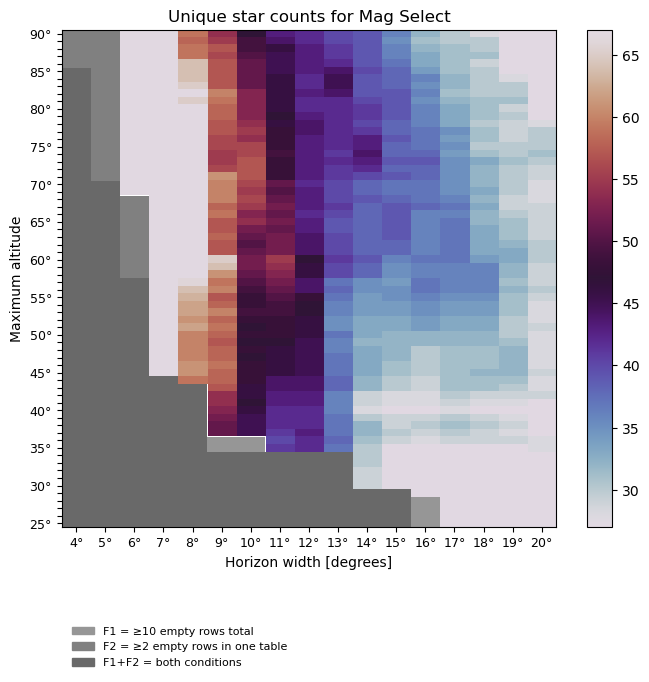

In [236]:
# Mag Select
grid_mag = sa.make_heatmap_grid(df["Mag"], metric="unicount")
grid_mag[grid_mag >= 0] -= 0 # expected value
fig, ax  = sa.plot_heatmap(grid_mag, "Unique star counts for Mag Select", 
                           cmap = "twilight", 
                           annotate=False,
                           fail1_color = "#969696",
                           fail2_color = "#808080",
                           failb_color = "#696969",
                           figsize=(7,7), 
                           clims = (27, 47, 67))
fig.savefig(savepath +"univals_mag_dark.png")

#### save all figs

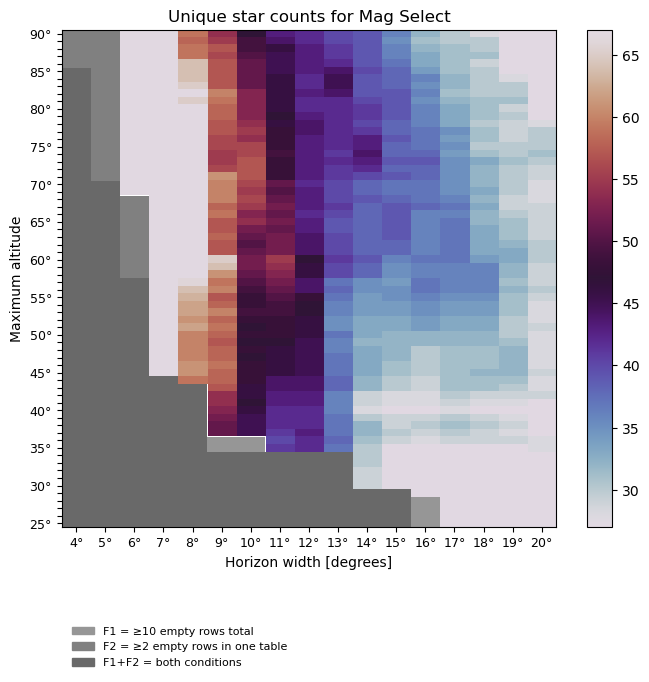

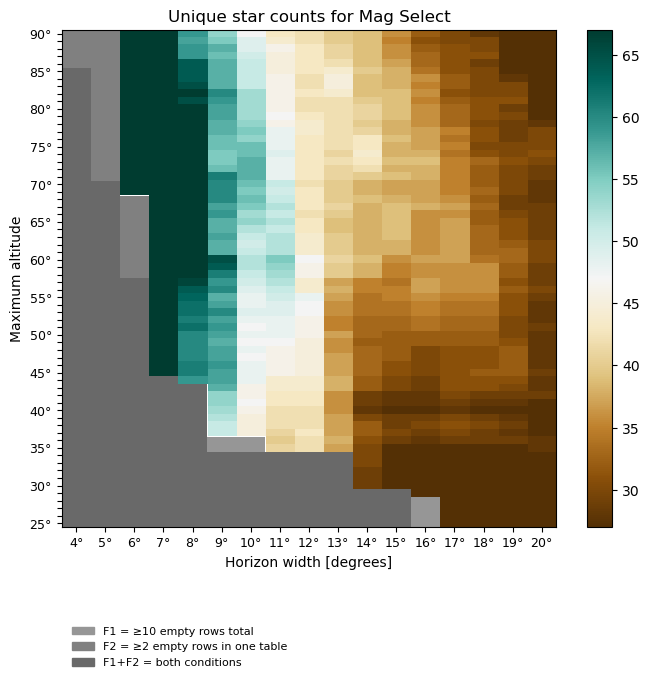

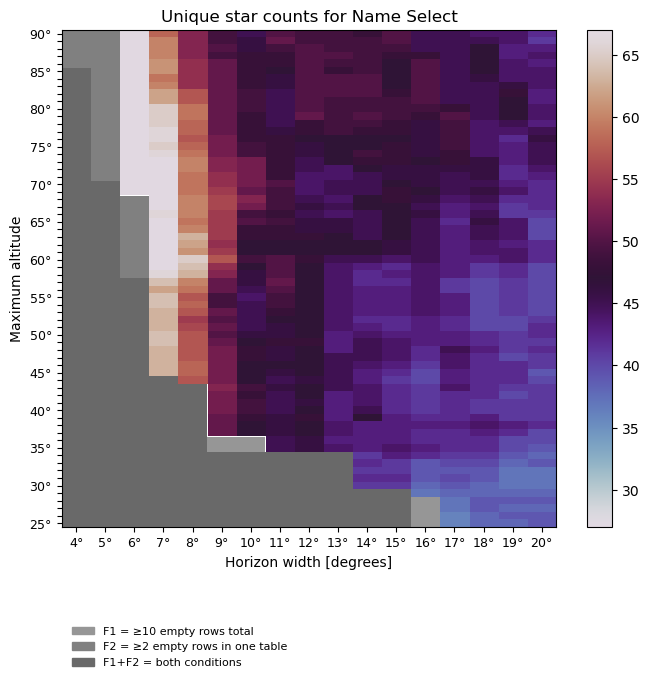

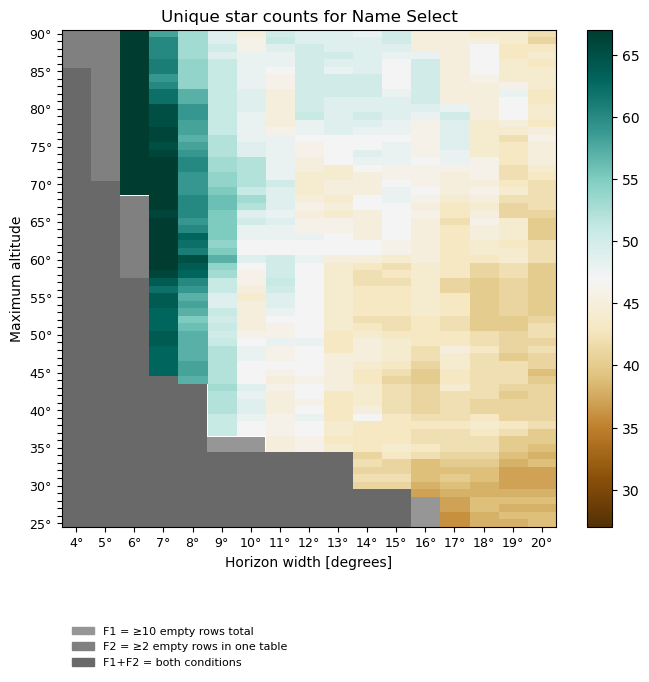

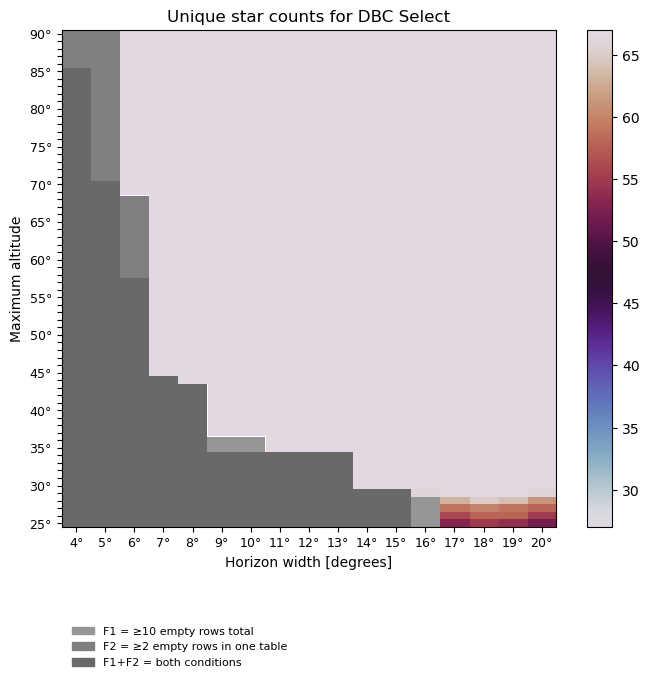

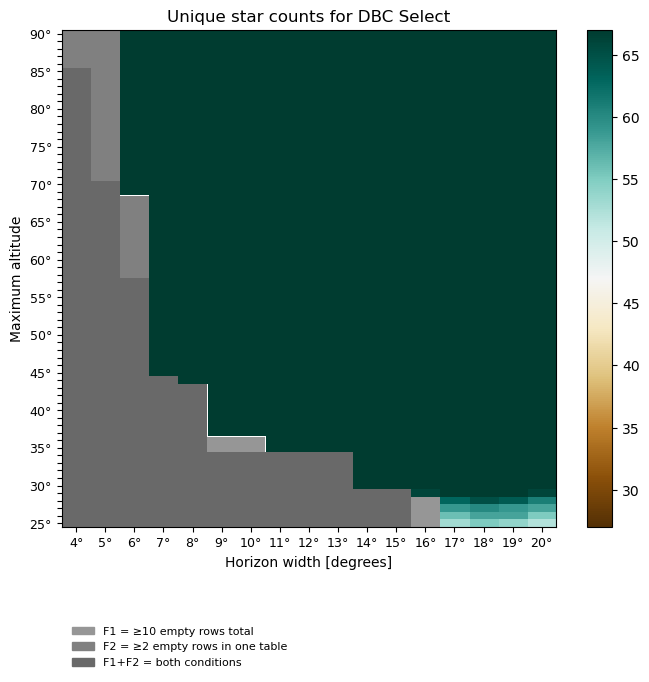

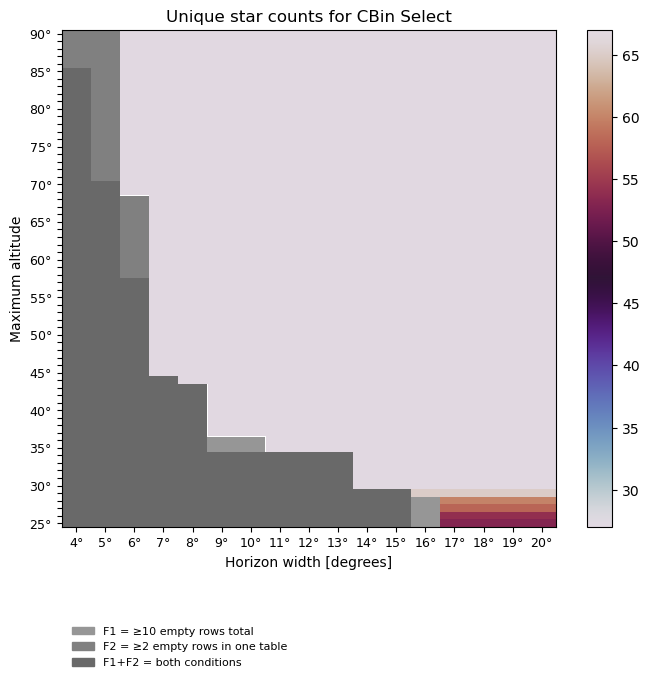

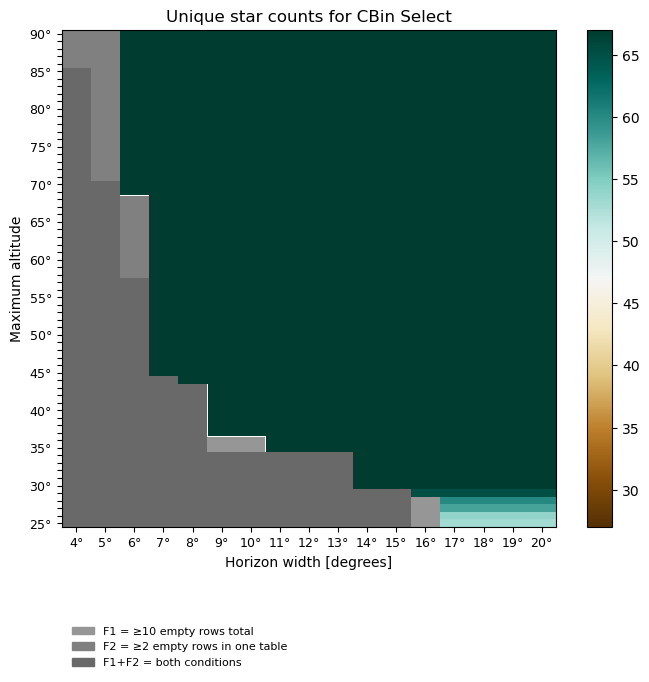

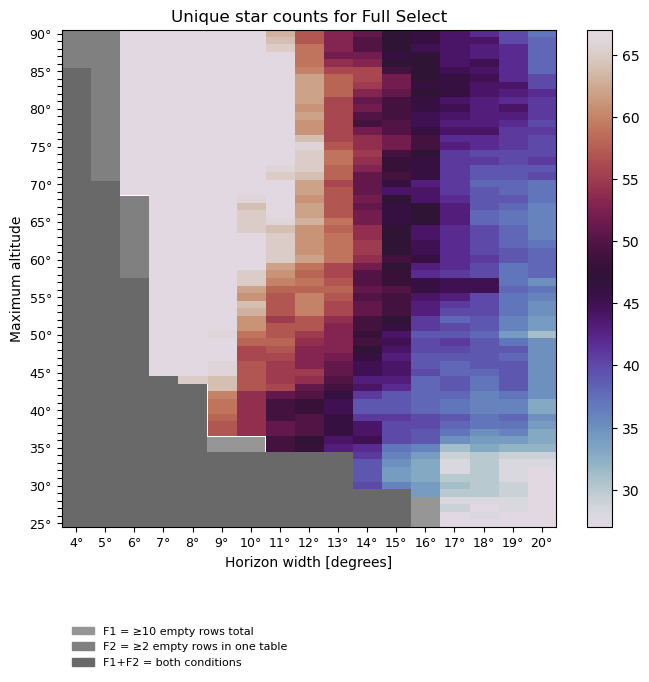

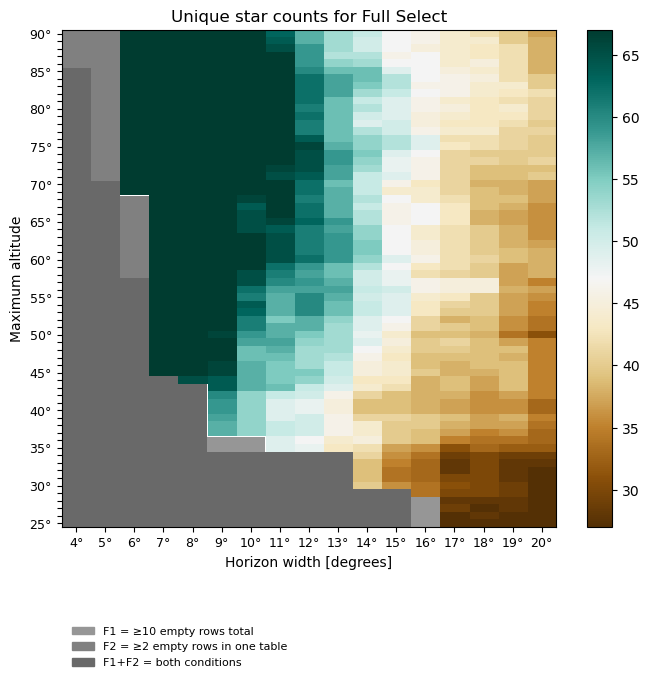

In [242]:
# save them all 
select_algs = ['Mag', 'Name', 'DBC', 'CBin', 'Full']
savepath = "./aea26/univals/"

for name in select_algs: 
    grid = sa.make_heatmap_grid(df[name], metric="unicount")
    # dark figure
    fig, ax  = sa.plot_heatmap(grid, "Unique star counts for " + name  + " Select", 
                            cmap = "twilight", 
                            annotate=False,
                            fail1_color = "#969696",
                            fail2_color = "#808080",
                            failb_color = "#696969",
                            figsize=(7,7), 
                            clims = (uscNP-20, uscNP, uscNP+20))
    fig.savefig(savepath + "univals_" + name + "_dark.png")
    # light figure
    fig, ax  = sa.plot_heatmap(grid, "Unique star counts for " + name  + " Select", 
                           cmap = "BrBG", 
                           annotate=False, 
                           figsize=(7,7), 
                           fail1_color = "#969696",
                           fail2_color = "#808080",
                           failb_color = "#696969",
                           clims = (uscNP-20, uscNP, uscNP+20))
    fig.savefig(savepath + "univals_" + name + "_light.png")

### Ratio heatmaps

#### R0

##### testing

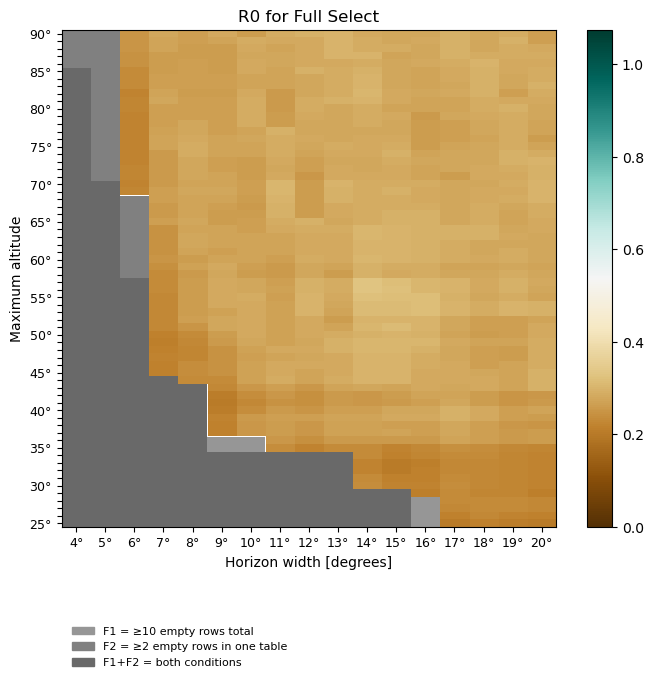

In [253]:
# Full Select
grid = sa.make_heatmap_grid(df["Full"], metric="R0")
fig, ax  = sa.plot_heatmap(grid, "R0 for Full Select", 
                           cmap = "BrBG", 
                           annotate=False, 
                           figsize=(7,7), 
                        #    fail1_color = "#444444",
                        #    fail2_color = "#242424",
                        #    failb_color = "#0D0D0D",
                           fail1_color = "#969696",
                           fail2_color = "#808080",
                           failb_color = "#696969",
                           clims = (R0NP-R0NP, R0NP, R0NP+R0NP))
#fig.savefig(savepath +"univals_mag_light.png")

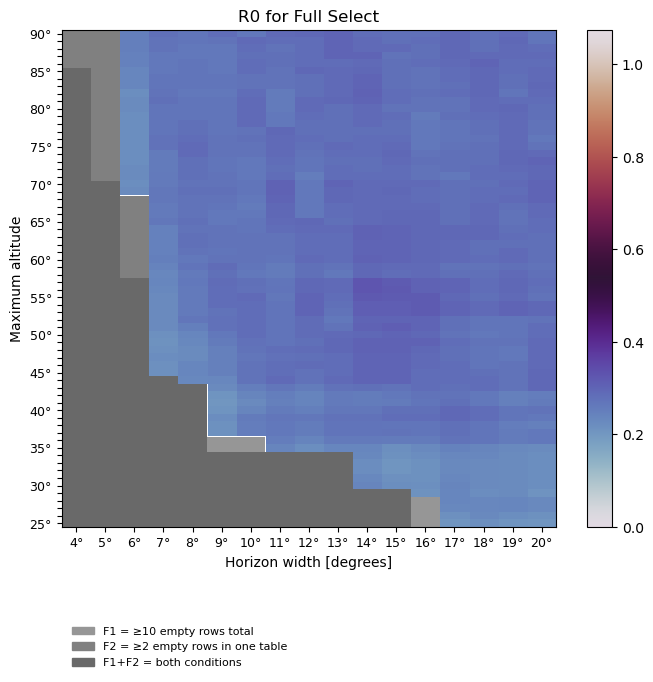

In [255]:
# Full Select
grid = sa.make_heatmap_grid(df["Full"], metric="R0")
fig, ax  = sa.plot_heatmap(grid, "R0 for Full Select", 
                           cmap = "twilight", 
                           annotate=False,
                           fail1_color = "#969696",
                           fail2_color = "#808080",
                           failb_color = "#696969",
                           figsize=(7,7), 
                           clims = (0, R0NP, 2*R0NP))
#
#fig.savefig(savepath +"univals_mag_dark.png")

##### save all figs

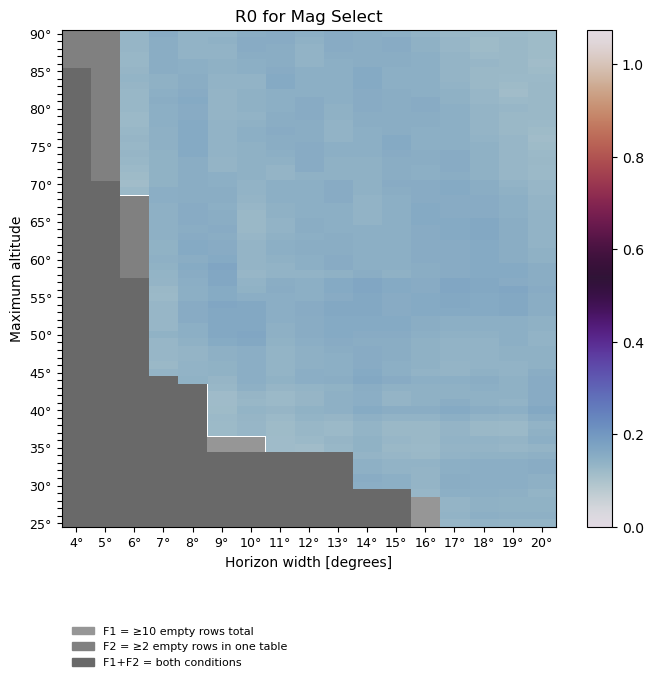

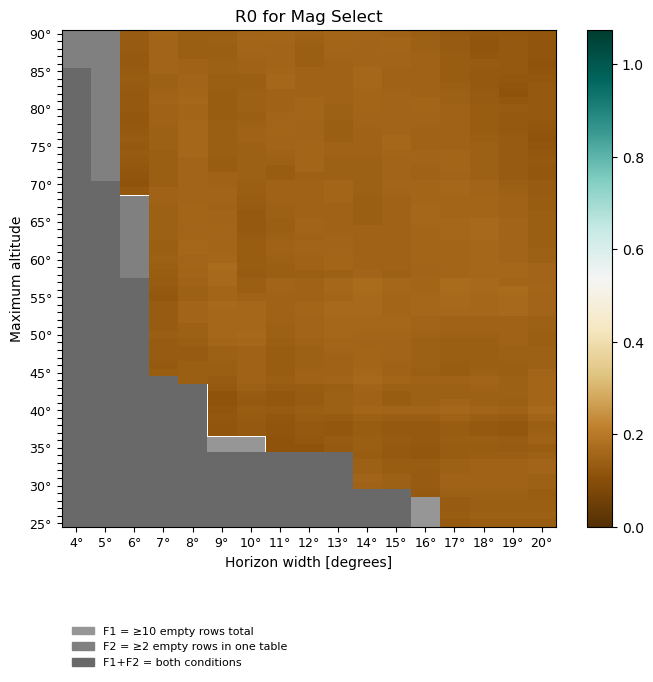

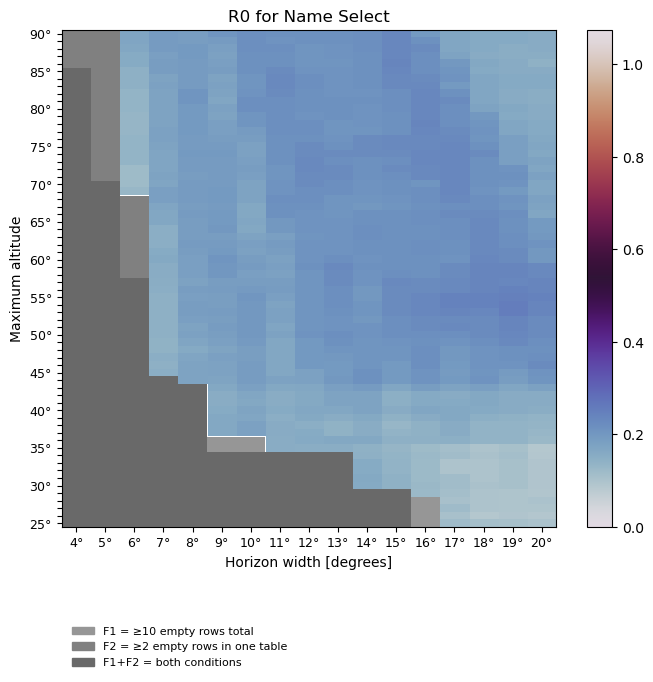

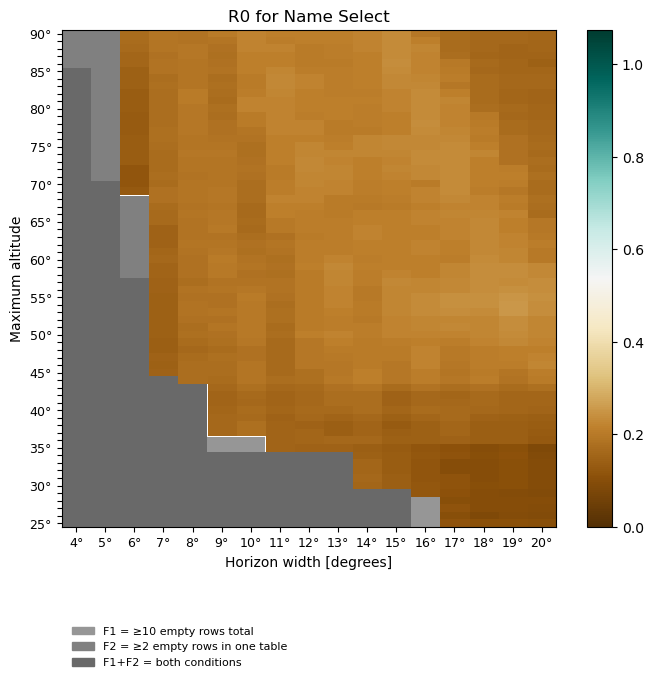

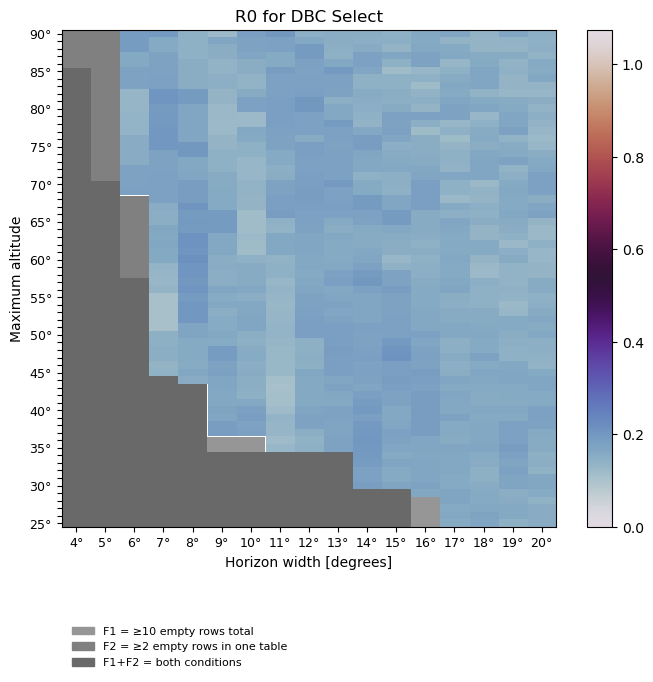

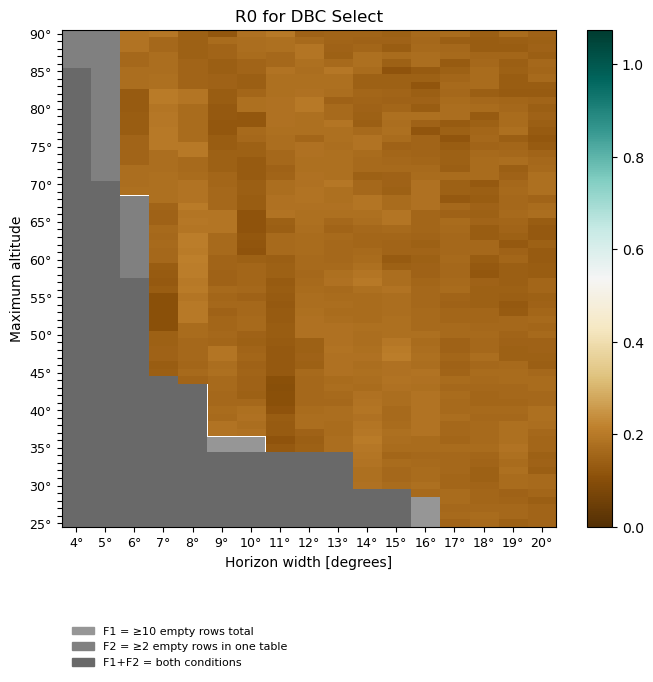

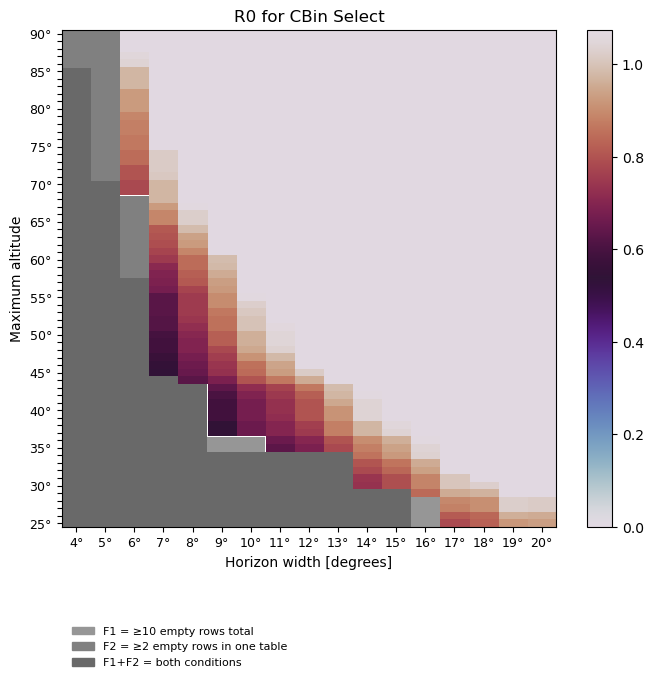

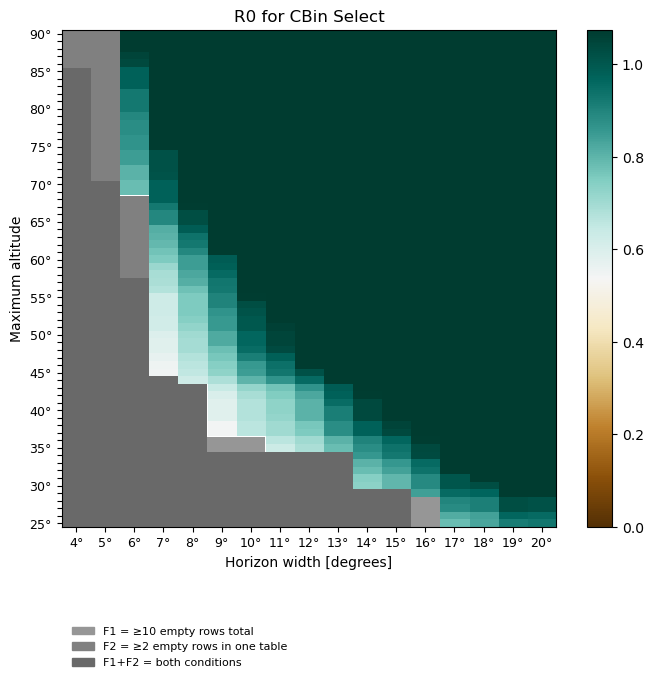

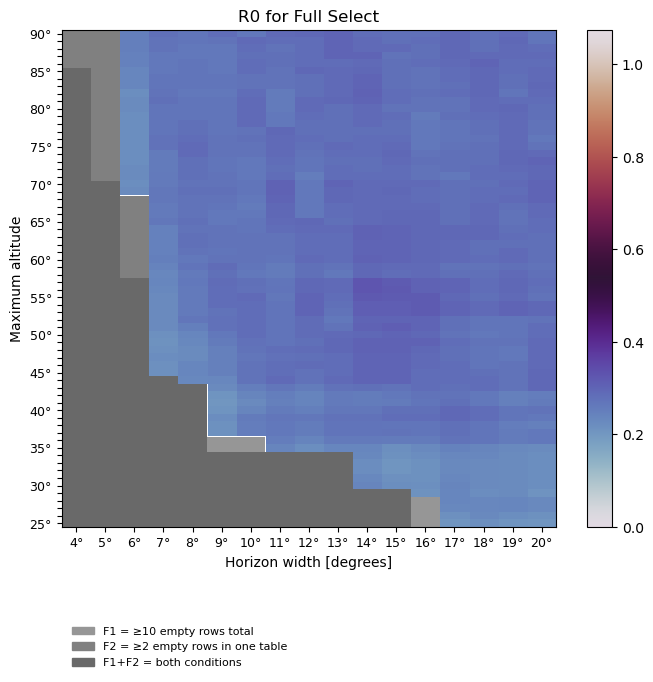

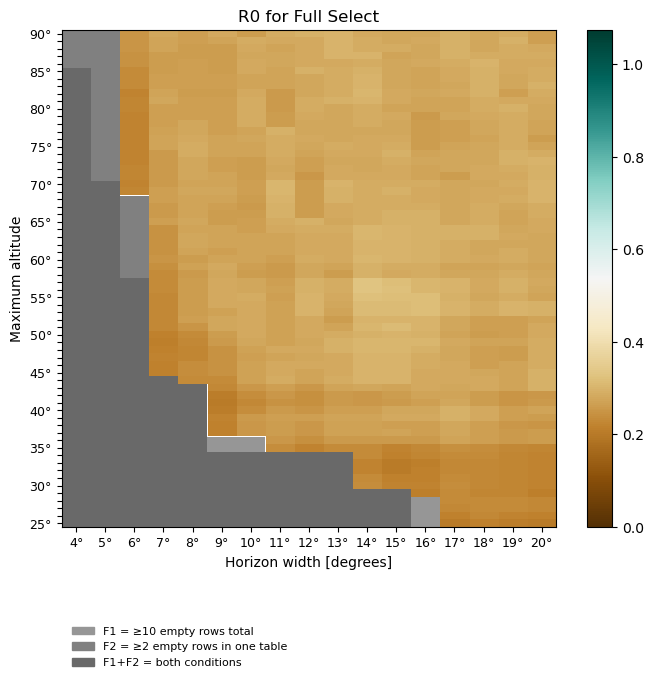

In [256]:
# save them all 
select_algs = ['Mag', 'Name', 'DBC', 'CBin', 'Full']
savepath = "./aea26/R0/"

for name in select_algs: 
    grid = sa.make_heatmap_grid(df[name], metric="R0")
    # dark figure
    fig, ax  = sa.plot_heatmap(grid, "R0 for " + name  + " Select", 
                            cmap = "twilight", 
                            annotate=False,
                            fail1_color = "#969696",
                            fail2_color = "#808080",
                            failb_color = "#696969",
                            figsize=(7,7), 
                            clims = (0, R0NP, 2*R0NP))
    fig.savefig(savepath + "R0_" + name + "_dark.png")
    # light figure
    fig, ax  = sa.plot_heatmap(grid, "R0 for " + name  + " Select", 
                           cmap = "BrBG", 
                           annotate=False, 
                           figsize=(7,7), 
                           fail1_color = "#969696",
                           fail2_color = "#808080",
                           failb_color = "#696969",
                           clims = (0, R0NP, 2*R0NP))
    fig.savefig(savepath + "R0_" + name + "_light.png")

#### R1

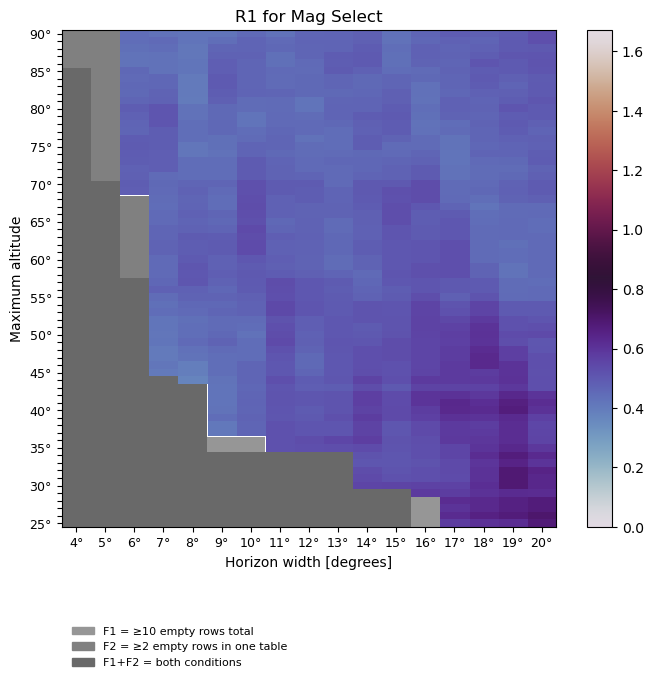

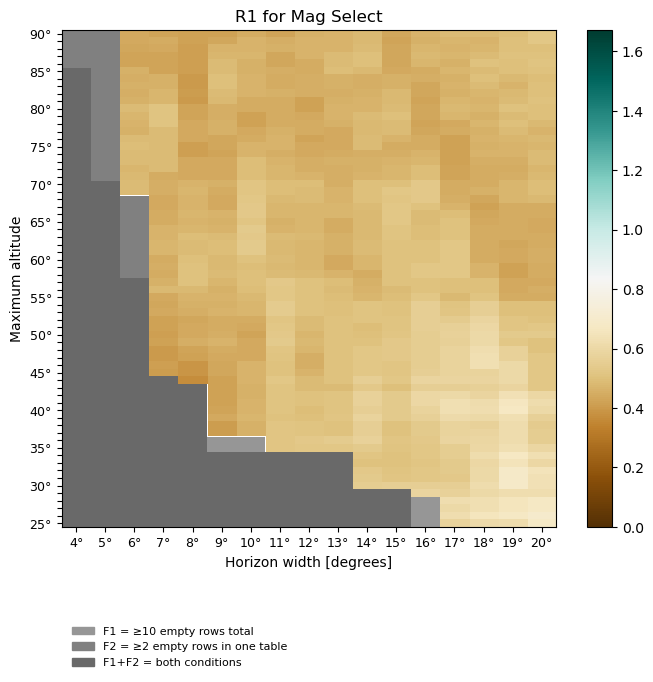

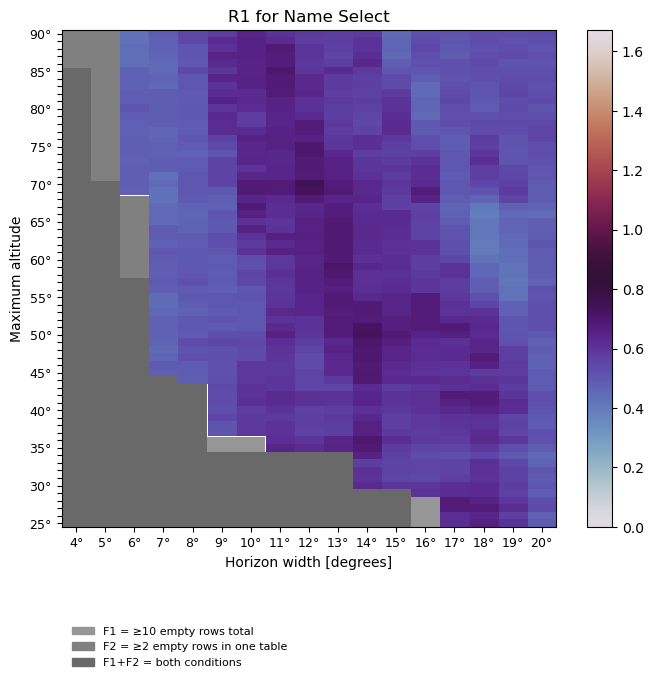

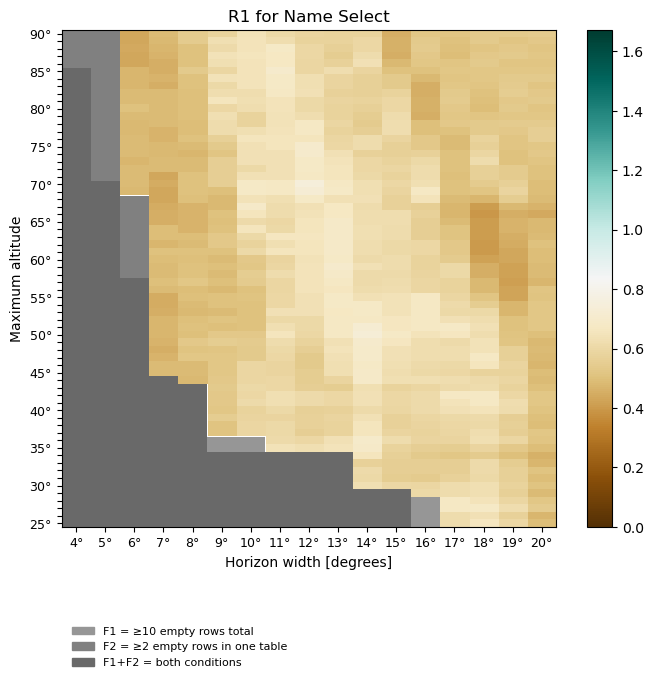

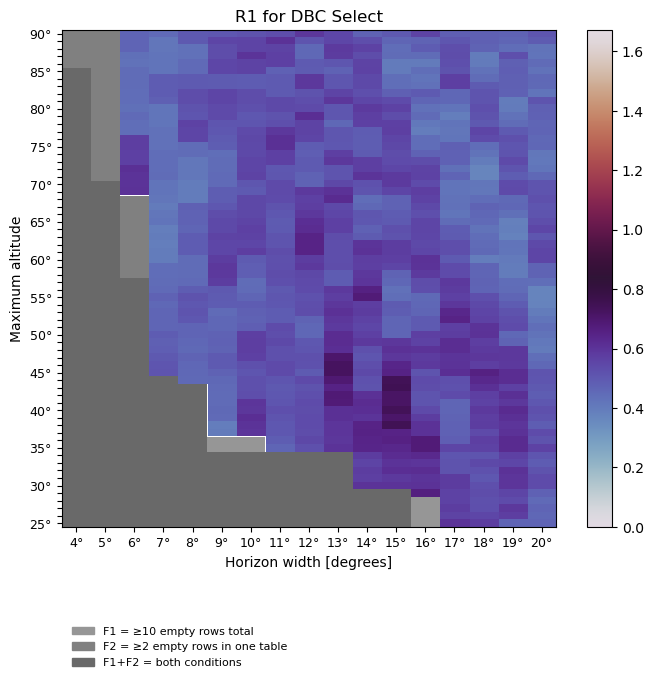

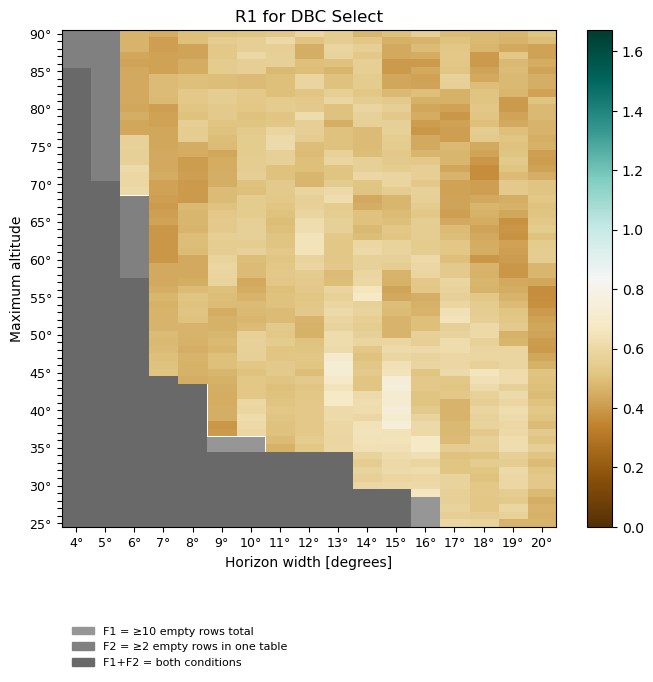

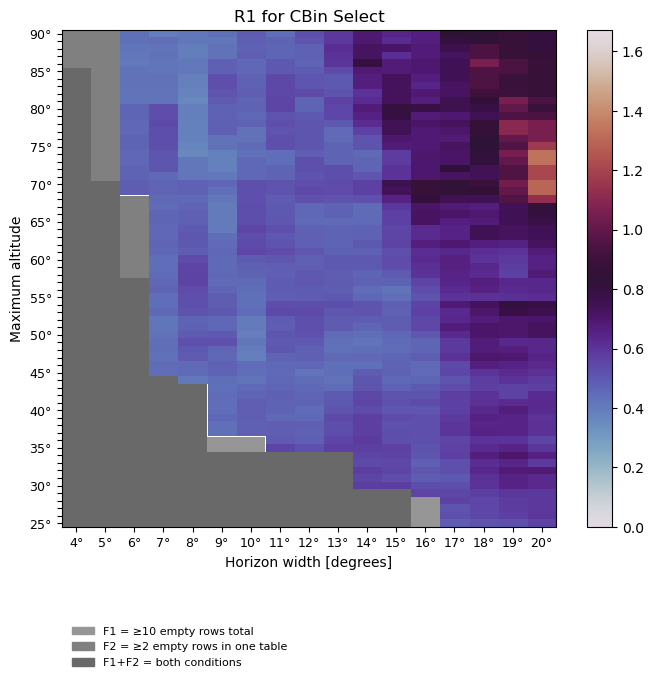

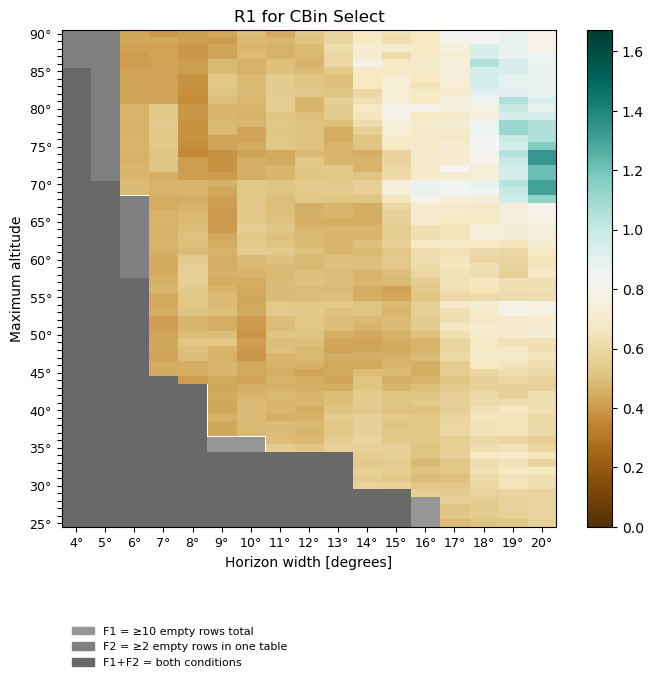

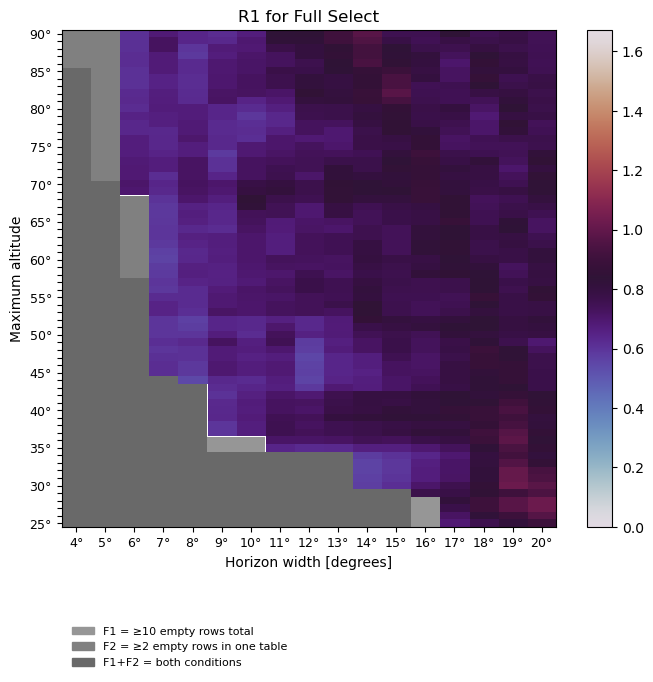

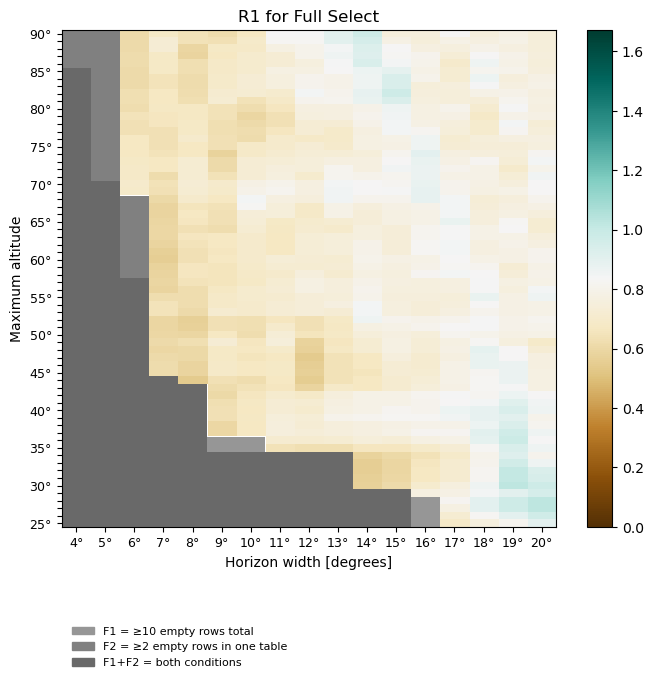

In [259]:
# save them all 
select_algs = ['Mag', 'Name', 'DBC', 'CBin', 'Full']
savepath = "./aea26/R1/" 

for name in select_algs: 
    grid = sa.make_heatmap_grid(df[name], metric="R1")
    # dark figure
    fig, ax  = sa.plot_heatmap(grid, "R1 for " + name  + " Select", 
                            cmap = "twilight", 
                            annotate=False,
                            fail1_color = "#969696",
                            fail2_color = "#808080",
                            failb_color = "#696969",
                            figsize=(7,7), 
                            clims = (0, R1NP, 2*R1NP))
    fig.savefig(savepath + "R1_" + name + "_dark.png")
    # light figure
    fig, ax  = sa.plot_heatmap(grid, "R1 for " + name  + " Select", 
                           cmap = "BrBG", 
                           annotate=False, 
                           figsize=(7,7), 
                           fail1_color = "#969696",
                           fail2_color = "#808080",
                           failb_color = "#696969",
                           clims = (0, R1NP, 2*R1NP))
    fig.savefig(savepath + "R1_" + name + "_light.png")

#### S

In [289]:
df["Full"]["S"]

0       1.064000
1       0.954198
2       0.961240
3       0.961240
4       0.889706
          ...   
1117         NaN
1118         NaN
1119         NaN
1120         NaN
1121         NaN
Name: S, Length: 1122, dtype: float64

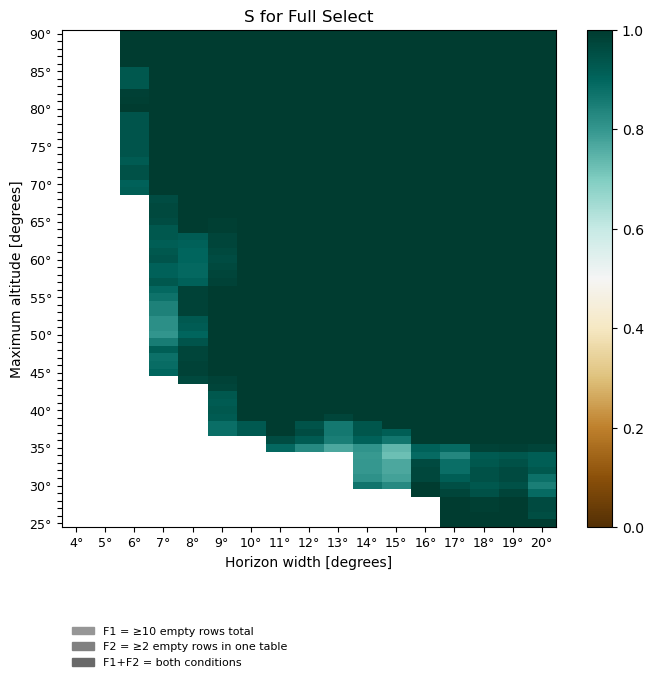

In [286]:
# Full Select
grid = sa.make_heatmap_grid(df["Full"], metric="S")
fig, ax  = sa.plot_heatmap(grid, "S for Full Select", 
                           cmap = "BrBG", 
                           annotate=False, 
                           figsize=(7,7), 
                           fail1_color = "#969696",
                           fail2_color = "#808080",
                           failb_color = "#696969",
                           clims = (0, 1)
                           )
#fig.savefig(savepath +"univals_mag_light.png")

In [ ]:
# save them all 
select_algs = ['Mag', 'Name', 'DBC', 'CBin', 'Full']
savepath = "./aea26/R1/" 

for name in select_algs: 
    grid = sa.make_heatmap_grid(df[name], metric="R1")
    # dark figure
    fig, ax  = sa.plot_heatmap(grid, "R1 for " + name  + " Select", 
                            cmap = "twilight", 
                            annotate=False,
                            fail1_color = "#969696",
                            fail2_color = "#808080",
                            failb_color = "#696969",
                            figsize=(7,7), 
                            clims = (0, R1NP, 2*R1NP))
    fig.savefig(savepath + "R1_" + name + "_dark.png")
    # light figure
    fig, ax  = sa.plot_heatmap(grid, "R1 for " + name  + " Select", 
                           cmap = "BrBG", 
                           annotate=False, 
                           figsize=(7,7), 
                           fail1_color = "#969696",
                           fail2_color = "#808080",
                           failb_color = "#696969",
                           clims = (0, R1NP, 2*R1NP))
    fig.savefig(savepath + "R1_" + name + "_light.png")

#### misc

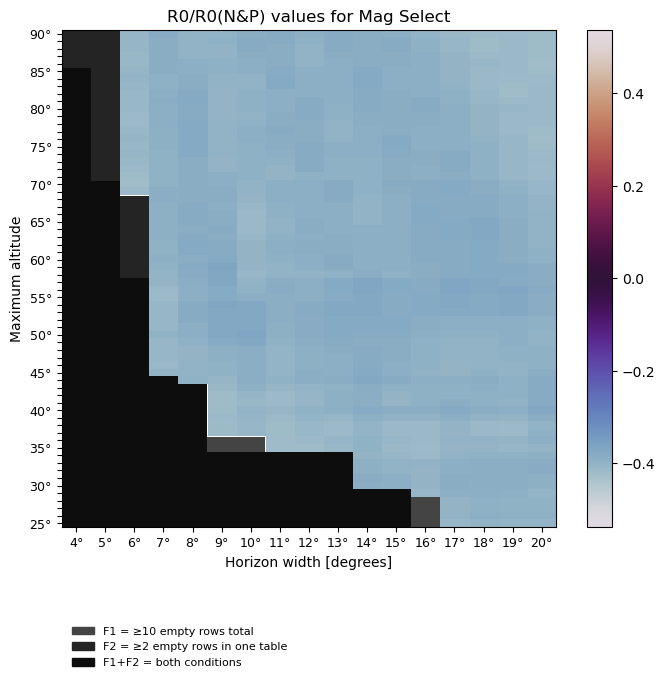

In [ ]:
# Mag Select
grid_mag = sa.make_heatmap_grid(df["Mag"], metric="R0")
grid_mag[grid_mag >= 0] -= R0NP # expected R0
fig, ax  = sa.plot_heatmap(grid_mag, "R0/R0(N&P) values for Mag Select", cmap = "twilight", annotate=False, figsize=(7,7), clims = (-R0NP, 0, R0NP))

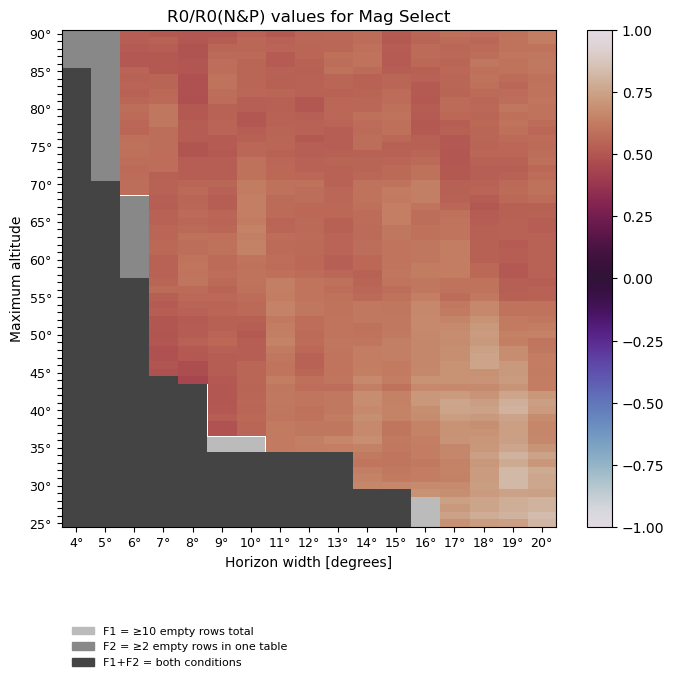

In [ ]:
# Mag Select

grid_mag = sa.make_heatmap_grid(df["Mag"], metric="R1")
grid_mag[grid_mag >= 0] /= 0.83562 # expected R1
fig, ax  = sa.plot_heatmap(grid_mag, "R0/R0(N&P) values for Mag Select", cmap = "twilight", annotate=False, figsize=(7,7), clims = (-1, 0, 1))

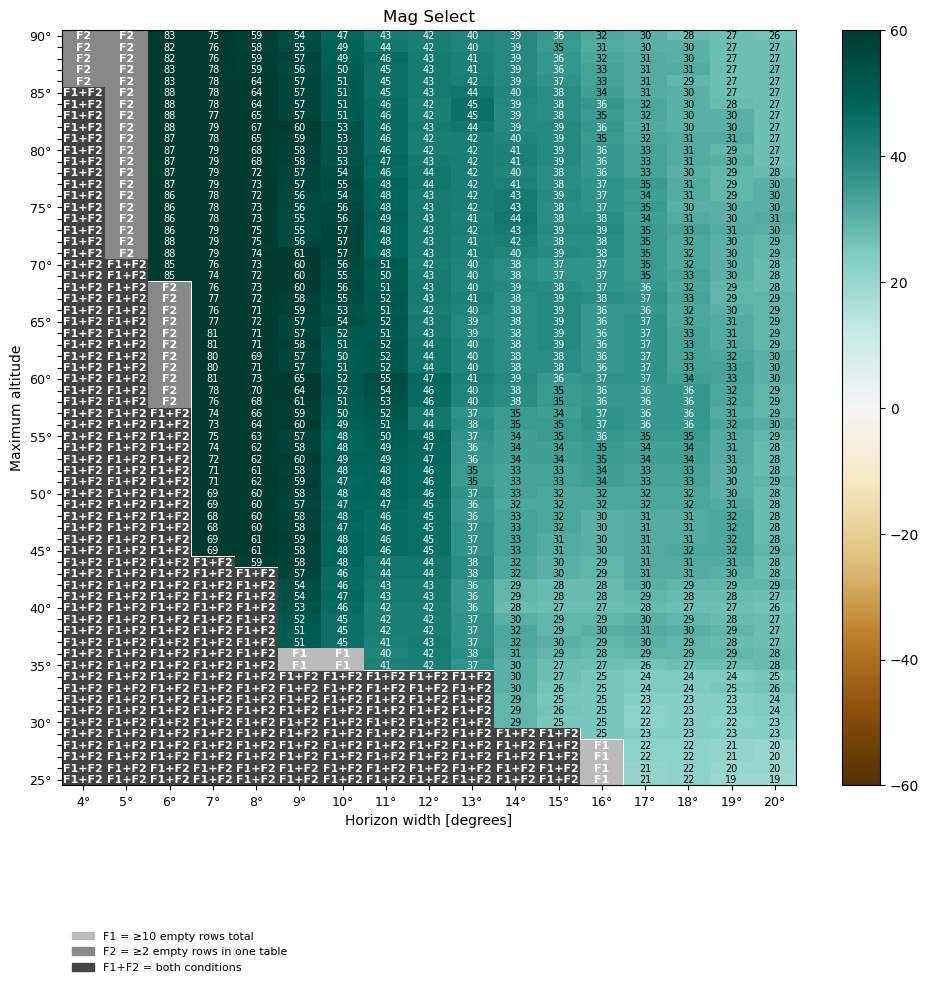

In [ ]:
# Mag Select

grid_mag = sa.make_heatmap_grid(df["Mag"],metric="unicount")
grid_mag[grid_mag >= 0] -= 0 # expected number of stars
fig, ax  = sa.plot_heatmap(grid_mag, "Mag Select", cmap = "BrBG", annotate=True, figsize=(10,10), clim = 60)

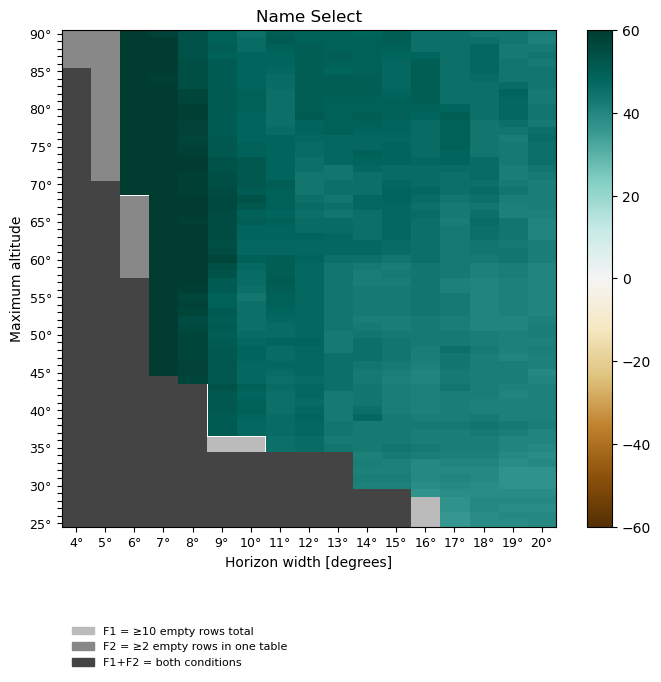

In [ ]:
# Name Select

grid_name = sa.make_heatmap_grid(df["Name"])
grid_name[grid_name >= 0] -= 0 # expected number of stars
fig, ax  = sa.plot_heatmap(grid_name, "Name Select", cmap = "BrBG", annotate=False, figsize=(7, 7), clim = 60)

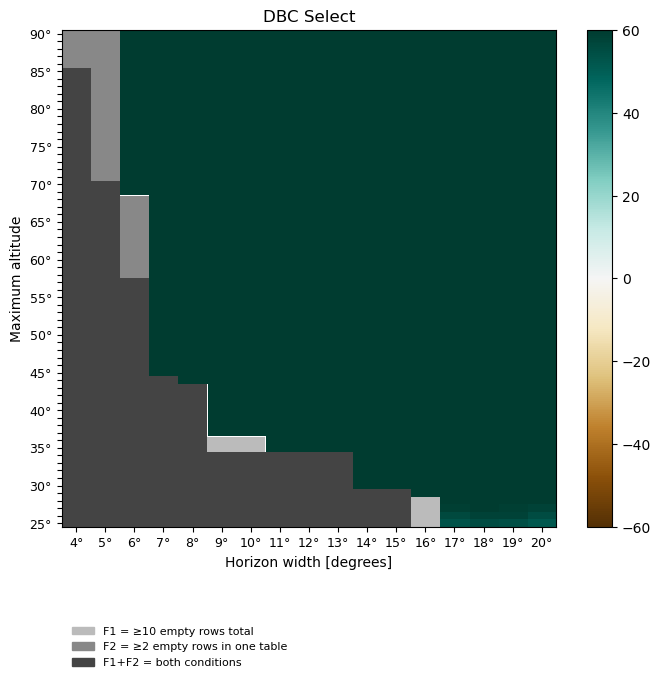

In [ ]:
# DBC Select

grid_dbc = sa.make_heatmap_grid(df["DBC"])
grid_dbc[grid_dbc >= 0] -= 0 # expected number of stars
fig, ax  = sa.plot_heatmap(grid_dbc, "DBC Select", cmap = "BrBG", annotate=False, figsize=(7, 7), clim = 60)

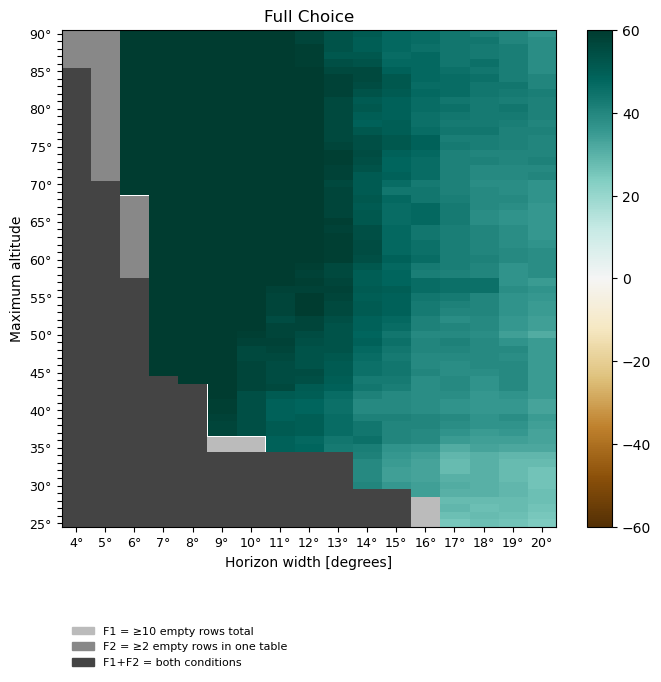

In [ ]:
# Full Choice Select

grid_full = sa.make_heatmap_grid(df["Full"])
grid_full[grid_full >= 0] -= 0 # expected number of stars
fig, ax  = sa.plot_heatmap(grid_full, "Full Choice", cmap = "BrBG", annotate=False, figsize=(7, 7), clim = 60)

### Histograms

(<Figure size 700x400 with 1 Axes>,
 <Axes: title={'center': 'Histogram — horizon width 10°, max alt 60'}, xlabel='Bin offset k', ylabel='Star count C(k)'>)

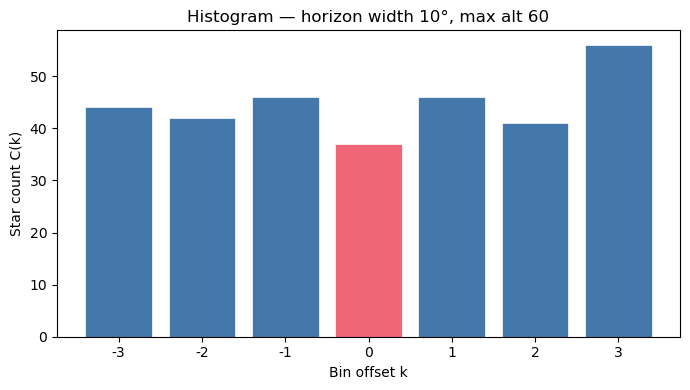

In [ ]:
sa.plot_histogram(df["Mag"], horizon_width=10, alt_hi=60)

# MISC

In [ ]:
# def plot_heatmap_no_labels(grid, title="", **kwargs):
#     fig, ax = sa.plot_heatmap(grid, title, **kwargs)
#     for txt in ax.texts:
#         txt.set_visible(False)
#     return fig, ax

# plot_heatmap_no_labels(grid_mag, "Mag Select")

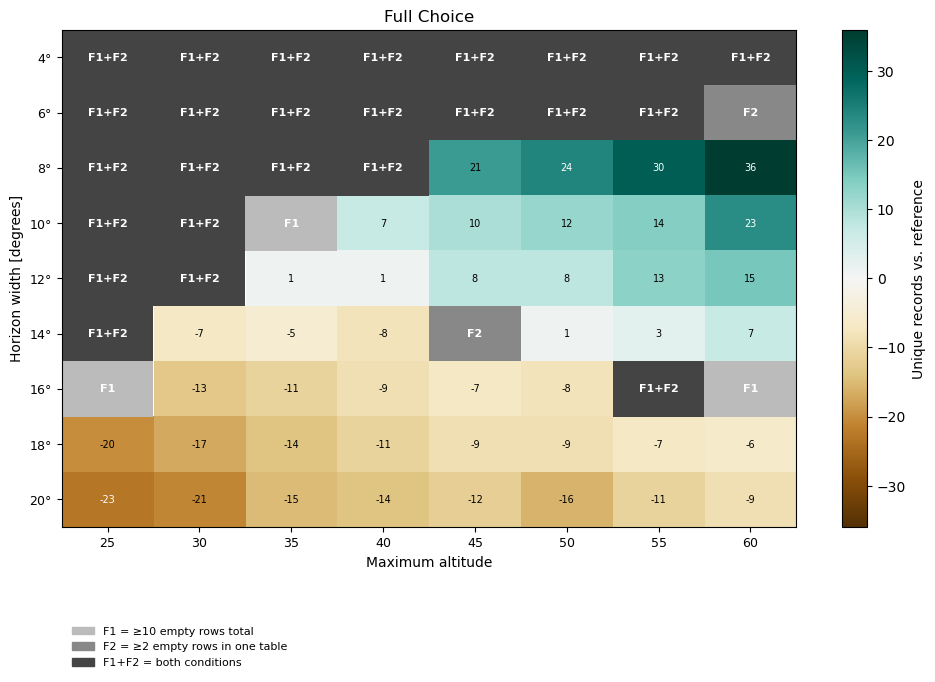

In [ ]:
importlib.reload(sa)

grid_full = sa.make_heatmap_grid(df["Full"])
grid_full[grid_full >= 0] -= 47 # expected number of stars
fig2, ax2 = sa.plot_heatmap(grid_full, "Full Choice")

In [ ]:
# grid = sa.make_heatmap_grid(df) # for plotting
# fig, ax = sa.plot_heatmap(grid)
# #fig.savefig("heatmap.png", dpi=150, bbox_inches="tight")